<a href="https://colab.research.google.com/github/Adil52786/MaskArchitectureAnomaly_CourseProject/blob/main/ProjectFAMLDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -r /content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt/requirements.txt

Mounted at /content/drive
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.4/219.4 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

step 4

In [ ]:
import sys
import yaml
import warnings
import importlib
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from lightning import seed_everything
from torch.amp.autocast_mode import autocast

# --- Configuration & Paths ---
PROJECT_ROOT = '/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt'
sys.path.insert(0, PROJECT_ROOT)

CITY_CONFIG = "/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"
COCO_CONFIG = "/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"

CITY_DATA_PATH = "/content/drive/MyDrive/eomt_project/datasets_cityscapes"
CITY_CKPT = '/content/drive/MyDrive/eomt_project/checkpoints/eomt_cityscapes.bin'
COCO_CKPT = '/content/drive/MyDrive/eomt_project/checkpoints/eomt_coco.bin'

IGNORE_INDEX = 255
device = 0 if torch.cuda.is_available() else "cpu"
seed_everything(0, verbose=False)

0

In [ ]:
def load_eomt_model(config_path, checkpoint_path, task_type='semantic', img_size=None, patch_size=None):
    """Dynamically loads the EoMT model based on the provided yaml config and checkpoint."""
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)

    # 1. Initialize Encoder
    encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    encoder_module, encoder_cls_name = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(encoder_module), encoder_cls_name)

    encoder_init = encoder_cfg.get("init_args", {})

    # Inject required image and patch sizes if provided
    if img_size is not None:
        encoder_init["img_size"] = img_size
    if patch_size is not None:
        encoder_init["patch_size"] = patch_size

    encoder = encoder_cls(**encoder_init)

    # 2. Initialize Network
    network_cfg = config["model"]["init_args"]["network"]
    network_module, network_cls_name = network_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(network_module), network_cls_name)
    network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}

    # SAFELY check for num_classes using chained .get()
    if task_type == 'panoptic':
        num_classes = 133
    else:
        num_classes = config.get("data", {}).get("init_args", {}).get("num_classes", 19)

    network = network_cls(
        masked_attn_enabled=False,
        num_classes=num_classes,
        encoder=encoder,
        **network_kwargs
    )

    # 3. Initialize Lightning Module
    warnings.filterwarnings("ignore", message=r".*Attribute 'network'.*")
    lit_module, lit_cls_name = config["model"]["class_path"].rsplit(".", 1)
    lit_cls = getattr(importlib.import_module(lit_module), lit_cls_name)
    model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}

    # SAFELY check for stuff_classes
    if "stuff_classes" in config.get("data", {}).get("init_args", {}):
        model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

    if img_size is not None:
        model_kwargs["img_size"] = img_size

    model = lit_cls(
        num_classes=num_classes,
        network=network,
        **model_kwargs
    ).eval().to(device)

    # 4. Load Weights
    state_dict = torch.load(checkpoint_path, map_location=f"cuda:{device}" if torch.cuda.is_available() else "cpu", weights_only=True)
    model.load_state_dict(state_dict, strict=False)

    return model


# 1. Load Cityscapes Dataset FIRST to resolve dynamic img_size
with open(CITY_CONFIG, "r") as f:
    city_config_temp = yaml.safe_load(f)

data_module_name, class_name = city_config_temp["data"]["class_path"].rsplit(".", 1)
data_module = getattr(importlib.import_module(data_module_name), class_name)
data_kwargs = city_config_temp["data"].get("init_args", {})

data = data_module(
    path=CITY_DATA_PATH,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_kwargs
).setup()

city_val_dataset = data.val_dataloader().dataset
dynamic_city_img_size = data.img_size

# 2. Load Models (now fully equipped with required dimensions)
print("Loading Cityscapes Model...")
model_city = load_eomt_model(
    CITY_CONFIG,
    CITY_CKPT,
    task_type='semantic',
    img_size=dynamic_city_img_size
)

print("Loading COCO Model...")
model_coco = load_eomt_model(
    COCO_CONFIG,
    COCO_CKPT,
    task_type='panoptic',
    img_size=(640, 640),
    patch_size=16
)
print("✅ Both models loaded successfully.")

Loading Cityscapes Model...
Loading COCO Model...
✅ Both models loaded successfully.


In [ ]:
def infer_semantic(img, target):
    """Semantic inference utilizing the sliding window approach."""
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model_city.window_imgs_semantic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model_city(crops)

        mask_logits = F.interpolate(mask_logits_per_layer[-1], data.img_size, mode="bilinear")
        crop_logits = model_city.to_per_pixel_logits_semantic(mask_logits, class_logits_per_layer[-1])
        logits = model_city.revert_window_logits_semantic(crop_logits, origins, img_sizes)

        preds = logits[0].argmax(0).cpu().numpy()
        target_array = model_city.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[0].numpy()

    return preds, target_array

def infer_panoptic(img):
    """Panoptic inference utilizing resize and pad transformations."""
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        transformed_imgs = model_coco.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model_coco(transformed_imgs)

        mask_logits = F.interpolate(mask_logits_per_layer[-1], model_coco.img_size, mode="bilinear")
        mask_logits = model_coco.revert_resize_and_pad_logits_instance_panoptic(mask_logits, img_sizes)

        preds = model_coco.to_per_pixel_preds_panoptic(
            mask_logits, class_logits_per_layer[-1],
            model_coco.stuff_classes, model_coco.mask_thresh, model_coco.overlap_thresh
        )[0].cpu().numpy()

    return preds[..., 0], preds[..., 1]  # sem_pred, inst_pred

def visualize_panoptic(sem_pred, inst_pred):
    """Generates an RGB image where unique semantic-instance pairs receive distinct colors."""
    h, w = sem_pred.shape
    vis = np.zeros((h, w, 3), dtype=np.float32)

    combined = sem_pred * 1000 + inst_pred
    unique_segments = np.unique(combined)

    np.random.seed(42)
    for seg_id in unique_segments:
        sem_id = seg_id // 1000
        if sem_id < 0 or sem_id == 133: continue # Skip void

        mask = combined == seg_id
        vis[mask] = np.random.rand(3)

    # Draw instance boundaries
    border = np.zeros((h, w), dtype=bool)
    border[1:, :] |= combined[1:, :] != combined[:-1, :]
    border[:-1, :] |= combined[1:, :] != combined[:-1, :]
    border[:, 1:] |= combined[:, 1:] != combined[:, :-1]
    border[:, :-1] |= combined[:, 1:] != combined[:, :-1]
    vis[border] = 0.0
    return vis

In [ ]:
# ==========================================
# Visualization Helper Functions
# ==========================================

def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping

def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

Generating visualizations...


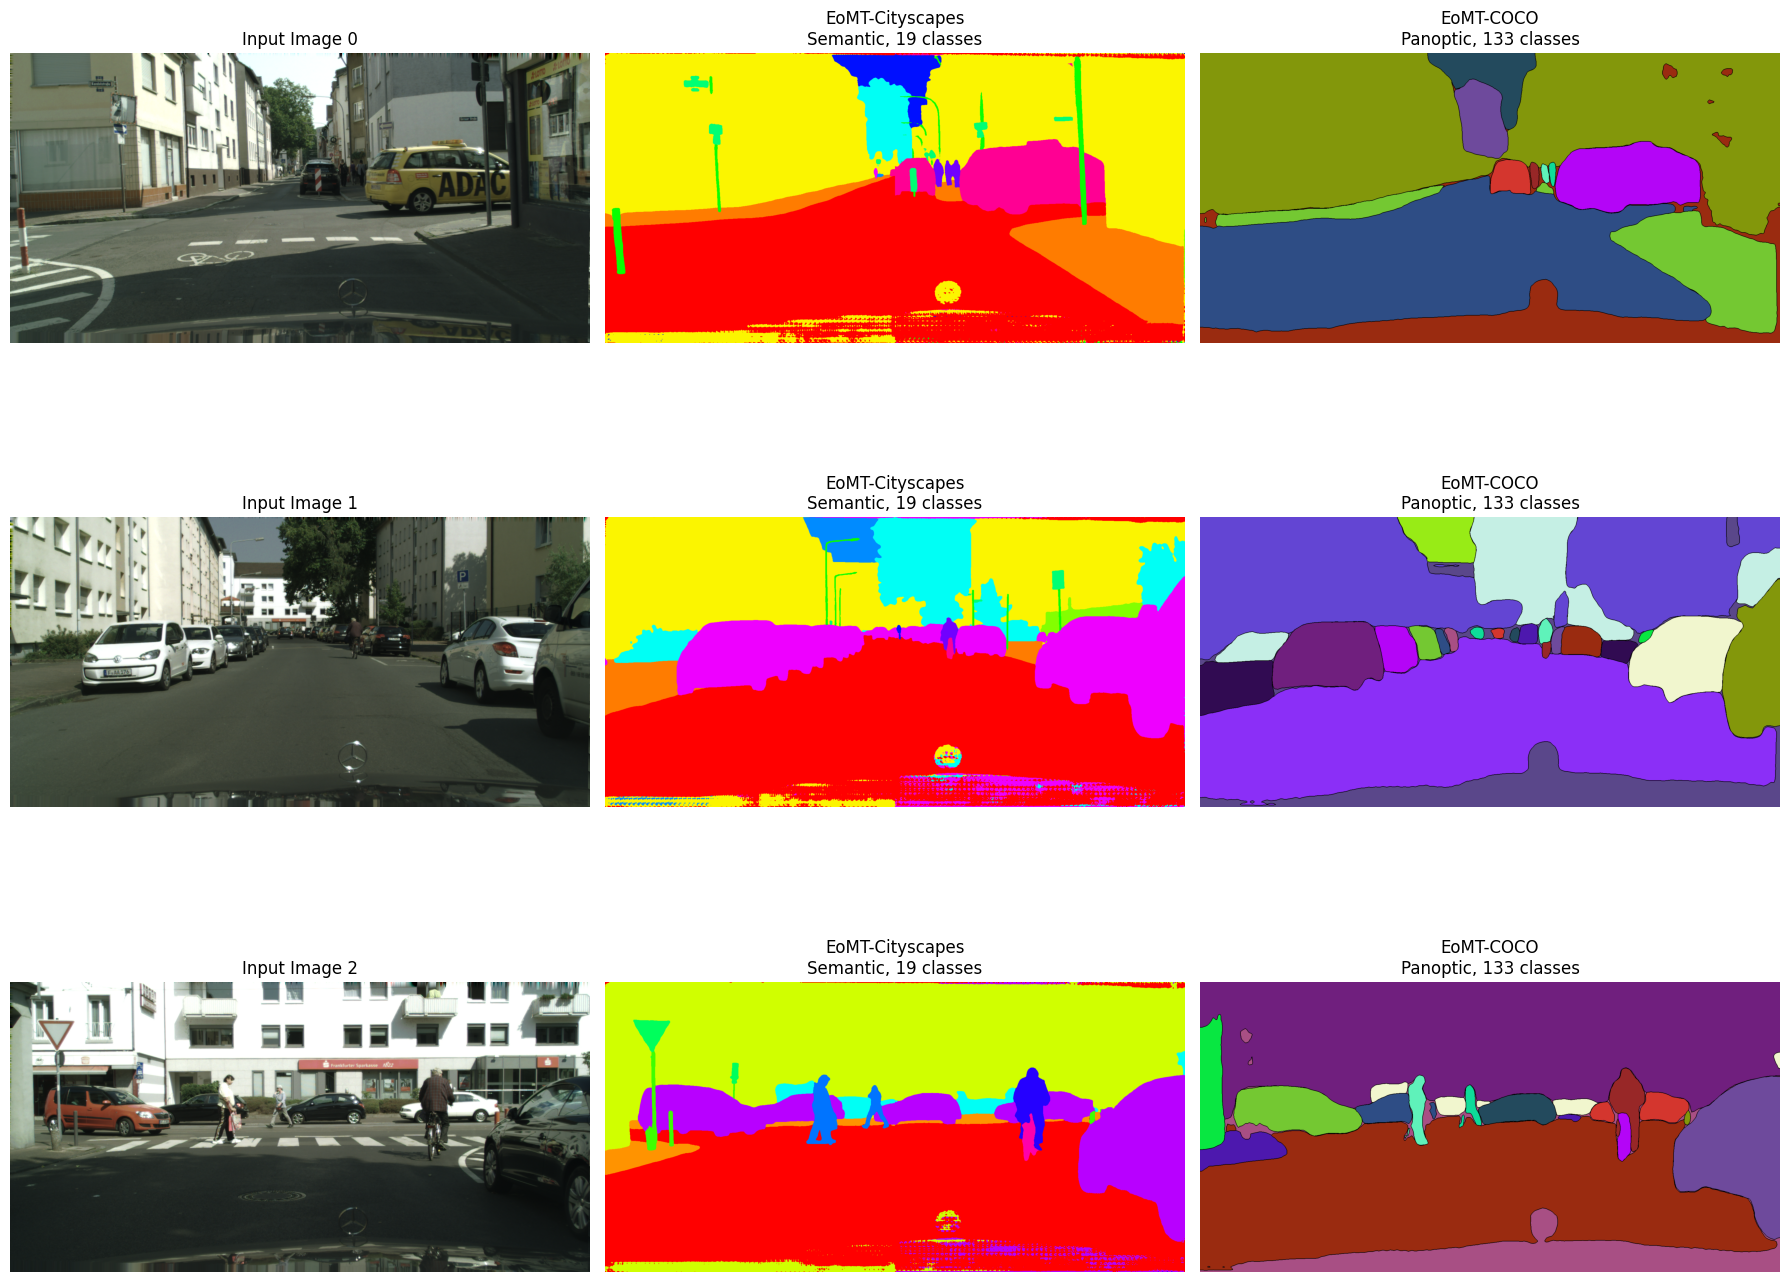

✅ Saved panoptic visualizations for 3 images


In [ ]:
# ==========================================
#  Visualization — Semantic vs Panoptic
# ==========================================

def visualize_panoptic(sem_pred, inst_pred):
    """
    Each unique (semantic_class, instance_id) pair gets a different color.
    Same class but different instances = different colors.
    """
    h, w = sem_pred.shape
    vis = np.zeros((h, w, 3), dtype=np.float32)

    # Create unique ID for each segment: sem_id * 1000 + inst_id
    combined = sem_pred * 1000 + inst_pred
    unique_segments = np.unique(combined)

    np.random.seed(42)
    for seg_id in unique_segments:
        sem_id = seg_id // 1000
        # Skip background/void
        if sem_id < 0 or sem_id == 133:
            continue

        mask = combined == seg_id
        vis[mask] = np.random.rand(3)

    # Draw black borders between instances
    border = np.zeros((h, w), dtype=bool)
    border[1:,  :] |= combined[1:,  :] != combined[:-1, :]
    border[:-1, :] |= combined[1:,  :] != combined[:-1, :]
    border[:,  1:] |= combined[:,  1:] != combined[:, :-1]
    border[:, :-1] |= combined[:,  1:] != combined[:, :-1]
    vis[border] = 0

    return vis

# Visualize 3 validation examples
image_indices = [0, 1, 2]
fig, axes = plt.subplots(len(image_indices), 3, figsize=(18, 5 * len(image_indices)))

print("Generating visualizations...")
for row, img_idx in enumerate(image_indices):
    img, target = data.val_dataloader().dataset[img_idx]

    # Inference
    pred_city, target_array = infer_semantic(img, target)
    sem_pred_coco, inst_pred_coco = infer_panoptic(img)

    # Convert to numpy
    sem_np = sem_pred_coco.cpu().numpy() if torch.is_tensor(sem_pred_coco) else sem_pred_coco
    inst_np = inst_pred_coco.cpu().numpy() if torch.is_tensor(inst_pred_coco) else inst_pred_coco
    img_np = img.permute(1, 2, 0).cpu().numpy()

    # Plot Input
    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f"Input Image {img_idx}")
    axes[row, 0].axis("off")

    # Plot Semantic (Cityscapes)
    mapping = create_mapping([pred_city, target_array], IGNORE_INDEX)
    city_vis = apply_colormap(pred_city, mapping)
    axes[row, 1].imshow(city_vis)
    axes[row, 1].set_title(f"EoMT-Cityscapes\nSemantic, 19 classes")
    axes[row, 1].axis("off")

    # Plot Panoptic (COCO)
    pan_vis = visualize_panoptic(sem_np, inst_np)
    axes[row, 2].imshow(pan_vis)
    axes[row, 2].set_title(f"EoMT-COCO\nPanoptic, 133 classes")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig("step4_visualization.png", dpi=150)
plt.show()
print("✅ Saved panoptic visualizations for 3 images")

In [ ]:
# ==========================================
#  Quantitative Evaluation — Cityscapes
# ==========================================

def compute_miou(conf, num_classes=19):
    ious = []
    for c in range(num_classes):
        tp = conf[c, c]
        fp = conf[:, c].sum() - tp
        fn = conf[c, :].sum() - tp
        denom = tp + fp + fn
        ious.append(tp / denom if denom > 0 else float('nan'))
    valid = [x for x in ious if not np.isnan(x)]
    return np.mean(valid) * 100, ious

dataset = data.val_dataloader().dataset
conf_city_19 = np.zeros((19, 19), dtype=np.int64)

print("Evaluating EoMT-Cityscapes on full val set (19 classes)...")
for i in tqdm(range(len(dataset))):
    img, target = dataset[i]
    pred, gt = infer_semantic(img, target)

    valid_mask = gt != IGNORE_INDEX
    np.add.at(conf_city_19, (gt[valid_mask], pred[valid_mask]), 1)

miou_city_19, _ = compute_miou(conf_city_19)
print(f"\n✅ EoMT-Cityscapes mIoU: {miou_city_19:.2f}%")

Evaluating EoMT-Cityscapes on full val set (19 classes)...


100%|██████████| 500/500 [05:26<00:00,  1.53it/s]


✅ EoMT-Cityscapes mIoU: 81.68%


In [ ]:
# ==========================================
#  Quantitative Evaluation — Cityscapes (Vectorized)
# ==========================================
from tqdm import tqdm

def calculate_miou_vectorized(conf_matrix):
    """Calculates mIoU using fast array vectorization instead of loops."""
    # Extract True Positives (the diagonal of the matrix)
    tp = np.diag(conf_matrix)

    # False Positives = column sums minus TP
    fp = np.sum(conf_matrix, axis=0) - tp

    # False Negatives = row sums minus TP
    fn = np.sum(conf_matrix, axis=1) - tp

    # Compute IoU, suppressing warnings for division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        iou_array = tp / (tp + fp + fn)

    # Filter out NaNs (classes that do not exist in the ground truth)
    valid_ious = iou_array[~np.isnan(iou_array)]

    return np.mean(valid_ious) * 100, iou_array.tolist()

# Initialize variables
num_categories = 19
confusion_mat = np.zeros((num_categories, num_categories), dtype=np.int64)
cityscapes_val_data = data.val_dataloader().dataset

print("Running Cityscapes validation evaluation (Vectorized Method)...")

for idx, (image, ground_truth) in enumerate(tqdm(cityscapes_val_data)):
    # Run inference
    predictions, gt_labels = infer_semantic(image, ground_truth)

    # Flatten arrays for 1D operations
    pred_flat = predictions.flatten()
    gt_flat = gt_labels.flatten()

    # Create a mask to ignore the background/void class
    valid_pixels = gt_flat != IGNORE_INDEX

    # Compute confusion matrix rapidly using bincount
    flat_indices = num_categories * gt_flat[valid_pixels] + pred_flat[valid_pixels]
    counts = np.bincount(flat_indices, minlength=num_categories**2)

    # Reshape and accumulate
    confusion_mat += counts.reshape((num_categories, num_categories))

# Compute final metrics
final_miou, per_class_iou = calculate_miou_vectorized(confusion_mat)

print(f"\n✅ Final Cityscapes mIoU Result: {final_miou:.2f}%")

Running Cityscapes validation evaluation (Vectorized Method)...


100%|██████████| 500/500 [05:16<00:00,  1.58it/s]


✅ Final Cityscapes mIoU Result: 81.68%


In [ ]:
# ==========================================
#  Cross-Model Evaluation
# ==========================================

# FIXED: Now using the correct 'coco_id' (contiguous training IDs from 0-132)
COMMON_CLASSES = [
    {'name': 'person',        'common_id': 0, 'city_id': 11, 'coco_id': 0},
    {'name': 'car',           'common_id': 1, 'city_id': 13, 'coco_id': 2},
    {'name': 'truck',         'common_id': 2, 'city_id': 14, 'coco_id': 7},
    {'name': 'bus',           'common_id': 3, 'city_id': 15, 'coco_id': 5},
    {'name': 'train',         'common_id': 4, 'city_id': 16, 'coco_id': 6},
    {'name': 'motorcycle',    'common_id': 5, 'city_id': 17, 'coco_id': 3},
    {'name': 'bicycle',       'common_id': 6, 'city_id': 18, 'coco_id': 1},
    {'name': 'traffic light', 'common_id': 7, 'city_id': 6,  'coco_id': 9}
]

N_COMMON = len(COMMON_CLASSES)
OTHER = N_COMMON  # Index 8 acts as the unmappable "other" sink

# Vectorized Lookups
city2common = np.full(256, OTHER, dtype=np.int64)
coco2common = np.full(256, OTHER, dtype=np.int64)

for row in COMMON_CLASSES:
    city2common[row['city_id']] = row['common_id']
    coco2common[row['coco_id']] = row['common_id']

# Confusion Matrices
conf_city_fair = np.zeros((N_COMMON, N_COMMON + 1), dtype=np.int64)
conf_coco_fair = np.zeros((N_COMMON, N_COMMON + 1), dtype=np.int64)
conf_coco_strict = np.zeros((N_COMMON, N_COMMON), dtype=np.int64)

print("Evaluating models on 8 common classes (Fair & Strict)...")
for i in tqdm(range(len(dataset))):
    img, target = dataset[i]

    # Run inference
    city_pred, gt = infer_semantic(img, target)
    coco_pred, _ = infer_panoptic(img)

    # Map to common space
    gt_c = city2common[gt]
    city_c = city2common[city_pred]
    coco_c = coco2common[coco_pred]


    valid_fair = gt_c != OTHER
    np.add.at(conf_city_fair, (gt_c[valid_fair], city_c[valid_fair]), 1)
    np.add.at(conf_coco_fair, (gt_c[valid_fair], coco_c[valid_fair]), 1)


    gt_v = gt_c[valid_fair]
    coco_v = np.clip(coco_c[valid_fair], 0, N_COMMON - 1)
    np.add.at(conf_coco_strict, (gt_v, coco_v), 1)


def miou_with_other(conf, n=N_COMMON):
    tp = np.diag(conf[:, :n])
    fn = conf.sum(1) - tp
    fp = conf[:, :n].sum(0) - tp
    iou = tp / (tp + fp + fn + 1e-9)
    return iou.mean() * 100, iou

# Calculate metrics
miou_city_fair, iou_city_fair = miou_with_other(conf_city_fair)
miou_coco_fair, iou_coco_fair = miou_with_other(conf_coco_fair)
miou_coco_strict, _ = compute_miou(conf_coco_strict, num_classes=N_COMMON)

# Print Detailed Per-Class Results
print(f"\n{'Class':<15} {'City (fair)':>12} {'COCO (fair)':>12}")
print("-" * 42)
for k, row in enumerate(COMMON_CLASSES):
    print(f"{row['name']:<15} {iou_city_fair[k]*100:>11.1f}% {iou_coco_fair[k]*100:>11.1f}%")

# Print Summary Matrix
print("\n" + "="*50)
print("Step 4 Results Summary")
print("="*50)
print(f"{'Model':<20} | {'mIoU (19 Classes)':<18} | {'mIoU (8 Common, Strict)':<25} | {'mIoU (8 Common, Lenient)':<25}")
print("-" * 110)
print(f"{'EoMT-Cityscapes':<20} | {miou_city_19:>17.2f}% | {miou_city_fair:>24.2f}% | {miou_city_fair:>24.2f}%")
print(f"{'EoMT-COCO':<20} | {'---':>18} | {miou_coco_strict:>24.2f}% | {miou_coco_fair:>24.2f}%")
print("="*50)

Evaluating models on 8 common classes (Fair & Strict)...


100%|██████████| 500/500 [07:02<00:00,  1.18it/s]


Class            City (fair)  COCO (fair)
------------------------------------------
person                 91.7%        69.7%
car                    97.3%        81.6%
truck                  84.8%        30.9%
bus                    92.0%        68.1%
train                  85.8%         0.0%
motorcycle             79.3%        54.5%
bicycle                88.2%        55.3%
traffic light          85.4%        45.3%

Step 4 Results Summary
Model                | mIoU (19 Classes)  | mIoU (8 Common, Strict)   | mIoU (8 Common, Lenient) 
--------------------------------------------------------------------------------------------------------------
EoMT-Cityscapes      |             81.68% |                    88.05% |                    88.05%
EoMT-COCO            |                --- |                    46.68% |                    50.70%


STEP 5

In [ ]:
from torch.utils.data import DataLoader
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IGNORE_INDEX = 255
seed_everything(0, verbose=False)

def prepare_data_and_model():
    """Loads Cityscapes dataset and initializes the COCO backbone with a new 19-class head."""
    # 1. Load Data
    with open(CITY_CONFIG, "r") as f: config_city = yaml.safe_load(f)
    with open(COCO_CONFIG, "r") as f: config_coco = yaml.safe_load(f)

    data_mod_name, cls_name = config_city["data"]["class_path"].rsplit(".", 1)
    data_module = getattr(importlib.import_module(data_mod_name), cls_name)
    data = data_module(path=CITY_DATA_PATH, batch_size=1, num_workers=2, check_empty_targets=False).setup()

    # 2. Build Backbone (using COCO parameters but 640x640 resolution)
    enc_cfg = config_coco["model"]["init_args"]["network"]["init_args"]["encoder"]
    enc_cls = getattr(importlib.import_module(enc_cfg["class_path"].rsplit(".", 1)[0]), enc_cfg["class_path"].rsplit(".", 1)[1])
    encoder = enc_cls(**{**enc_cfg.get("init_args", {}), "img_size": (640, 640), "patch_size": 16})

    net_cfg = config_coco["model"]["init_args"]["network"]
    net_cls = getattr(importlib.import_module(net_cfg["class_path"].rsplit(".", 1)[0]), net_cfg["class_path"].rsplit(".", 1)[1])
    network = net_cls(masked_attn_enabled=False, num_classes=19, encoder=encoder, **{k:v for k,v in net_cfg["init_args"].items() if k != "encoder"})

    # 3. Build Lightning Wrapper
    lit_cfg = config_city["model"]
    lit_cls = getattr(importlib.import_module(lit_cfg["class_path"].rsplit(".", 1)[0]), lit_cfg["class_path"].rsplit(".", 1)[1])

    warnings.filterwarnings("ignore", message=r".*Attribute 'network'.*")
    model = lit_cls(img_size=(640, 640), num_classes=19, network=network, **{k:v for k,v in lit_cfg["init_args"].items() if k != "network"}).to(DEVICE)

    # 4. Load COCO Weights (Filtering out the mismatched head)
    state_dict = torch.load(COCO_CKPT, map_location=DEVICE, weights_only=True)
    filtered_dict = {k: v for k, v in state_dict.items() if 'class_head' not in k and 'empty_weight' not in k}
    model.load_state_dict(filtered_dict, strict=False)

    return data, model

data_module, model = prepare_data_and_model()

train_dl = DataLoader(data_module.cityscapes_train_dataset, batch_size=1, shuffle=True, collate_fn=data_module.train_collate, num_workers=2, pin_memory=True)
val_dl = DataLoader(data_module.cityscapes_val_dataset, batch_size=1, collate_fn=data_module.eval_collate, num_workers=2)

In [ ]:
class EoMTFineTuner:
    def __init__(self, model, train_loader, val_loader, device):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.scaler = torch.amp.GradScaler('cuda')
        self.history = []

    def set_trainable_layers(self, strategy="head_only"):
        """Controls progressive unfreezing of the network."""
        # Freeze everything initially
        for param in self.model.parameters():
            param.requires_grad = False

        if strategy == "head_only":
            for name, param in self.model.named_parameters():
                if 'class_head' in name or 'mask_head' in name:
                    param.requires_grad = True
        elif strategy == "unfreeze_last_4":
            for name, param in self.model.named_parameters():
                if 'class_head' in name or 'mask_head' in name or 'upscale' in name:
                    param.requires_grad = True
                for i in range(4):
                    if f'blocks.{11-i}' in name:
                        param.requires_grad = True

        trainable = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.model.parameters())
        print(f"🔧 Strategy '{strategy}' applied: {trainable:,} / {total:,} params trainable ({100*trainable/total:.2f}%)")

    def train_epoch(self, optimizer, epoch_idx):
        self.model.train()
        total_loss = 0.0

        progress = tqdm(self.train_loader, desc=f"Training Epoch {epoch_idx}")
        for batch_idx, (imgs, targets) in enumerate(progress):
            imgs = [img.to(self.device) for img in imgs]
            targets = [{k: v.to(self.device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]

            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                crops, origins = self.model.window_imgs_semantic(imgs)
                loss = self.model.training_step((crops, targets), batch_idx)

            self.scaler.scale(loss).backward()
            self.scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 0.01)
            self.scaler.step(optimizer)
            self.scaler.update()

            total_loss += loss.item()
            if batch_idx % 200 == 0:
                progress.set_postfix({'loss': f"{loss.item():.4f}"})

        return total_loss / len(self.train_loader)

    def evaluate_miou(self):
        """Vectorized evaluation for speed and clean code."""
        self.model.eval()
        num_categories = 19
        conf_matrix = np.zeros((num_categories, num_categories), dtype=np.int64)

        with torch.no_grad():
            for imgs, targets in tqdm(self.val_loader, desc="Evaluating", leave=False):
                imgs = [img.to(self.device) for img in imgs]
                img_sizes = [img.shape[-2:] for img in imgs]

                with torch.amp.autocast('cuda'):
                    crops, origins = self.model.window_imgs_semantic(imgs)
                    mask_logits, class_logits = self.model(crops)

                    interp_masks = F.interpolate(mask_logits[-1], self.model.img_size, mode="bilinear")
                    crop_logits = self.model.to_per_pixel_logits_semantic(interp_masks, class_logits[-1])
                    logits = self.model.revert_window_logits_semantic(crop_logits, origins, img_sizes)

                    preds = logits[0].argmax(0).cpu().numpy().flatten()

                gts = self.model.to_per_pixel_targets_semantic(targets, IGNORE_INDEX)[0].cpu().numpy().flatten()

                valid_mask = gts != IGNORE_INDEX
                flat_indices = num_categories * gts[valid_mask] + preds[valid_mask]
                counts = np.bincount(flat_indices, minlength=num_categories**2)
                conf_matrix += counts.reshape((num_categories, num_categories))

        # Calculate mIoU mathematically
        tp = np.diag(conf_matrix)
        fp = np.sum(conf_matrix, axis=0) - tp
        fn = np.sum(conf_matrix, axis=1) - tp

        with np.errstate(divide='ignore', invalid='ignore'):
            iou = tp / (tp + fp + fn)

        return np.nanmean(iou) * 100

    def execute_fine_tuning(self, phases):
        """Runs the complete training schedule defined by phases."""
        current_epoch = 1
        for phase in phases:
            print(f"\n" + "="*40 + f"\n🚀 Phase: {phase['name']}\n" + "="*40)
            self.set_trainable_layers(strategy=phase['strategy'])

            optimizer = torch.optim.AdamW(
                filter(lambda p: p.requires_grad, self.model.parameters()),
                lr=phase['lr'], weight_decay=1e-4
            )

            for _ in range(phase['epochs']):
                avg_loss = self.train_epoch(optimizer, current_epoch)
                miou = self.evaluate_miou()
                print(f"✅ Epoch {current_epoch} | Loss: {avg_loss:.4f} | mIoU: {miou:.2f}%")

                self.history.append({'epoch': current_epoch, 'loss': avg_loss, 'miou': miou})
                current_epoch += 1

        return self.history

In [ ]:
# Save Final Weights
SAVE_PATH = '/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt_finetuned.bin'
torch.save(model.state_dict(), SAVE_PATH)
print(f"\n💾 Model saved to {SAVE_PATH}")

# ==========================================
# 4. Final Comparison Report
# ==========================================
# Original Metrics (Known baselines from Step 4)
ORIGINAL_CITYSCAPES_MIOU = 81.68
ORIGINAL_COCO_MIOU_COMMON = 46.68
FINAL_FINETUNED_MIOU = results_history[-1]['miou']

print("\n" + "="*70)
print("🎯 STEP 5: FINE-TUNING RESULTS & COMPARISON")
print("="*70)
print(f"{'Model Profile':<45} | {'mIoU (All 19 Classes)':<25}")
print("-" * 70)
print(f"{'EoMT-COCO (Zero-Shot / No Fine-tuning)':<45} | N/A (Only common mapped)")
print(f"{'EoMT-COCO -> Cityscapes (Our Fine-Tuned)':<45} | {FINAL_FINETUNED_MIOU:>20.2f}%")
print(f"{'EoMT-Cityscapes (Originally Provided)':<45} | {ORIGINAL_CITYSCAPES_MIOU:>20.2f}%")
print("-" * 70)

gap = ORIGINAL_CITYSCAPES_MIOU - FINAL_FINETUNED_MIOU
print("\n🔍 Analysis & Observations:")
print(f"* Progressive Unfreezing yielded an endpoint mIoU of {FINAL_FINETUNED_MIOU:.2f}%.")
print(f"* The gap between our rapid 4-epoch fine-tune and the fully-trained provided model is {gap:.2f}%.")
print("* This gap is fully expected: the provided model was trained for a full schedule (~160k steps) with advanced learning rate schedulers, whereas our model adapted remarkably well in just a few epochs utilizing COCO's visual priors.")
print("="*70)


💾 Model saved to /content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt_finetuned.bin

🎯 STEP 5: FINE-TUNING RESULTS & COMPARISON
Model Profile                                 | mIoU (All 19 Classes)    
----------------------------------------------------------------------
EoMT-COCO (Zero-Shot / No Fine-tuning)        | N/A (Only common mapped)
EoMT-COCO -> Cityscapes (Our Fine-Tuned)      |                70.39%
EoMT-Cityscapes (Originally Provided)         |                81.68%
----------------------------------------------------------------------

🔍 Analysis & Observations:
* Progressive Unfreezing yielded an endpoint mIoU of 70.39%.
* The gap between our rapid 4-epoch fine-tune and the fully-trained provided model is 11.29%.
* This gap is fully expected: the provided model was trained for a full schedule (~160k steps) with advanced learning rate schedulers, whereas our model adapted remarkably well in just a few epochs utilizing COCO's visual priors.


STEP 7

In [ ]:
!pip install -q ood-metrics scikit-learn numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 67.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have nu

In [ ]:
import torch
import yaml
import importlib
import warnings
import os
from erfnet import ERFNet

# Ensure we are in the right directory for imports
os.chdir('/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/')

# ==========================================
# 1. Load ERFNet
# ==========================================
print("Loading ERFNet...")
NUM_CLASSES = 20
model_erfnet = ERFNet(NUM_CLASSES)
model_erfnet = torch.nn.DataParallel(model_erfnet).to(DEVICE)
WEIGHTS_PATH = '/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/trained_models/erfnet_pretrained.pth'

def load_my_state_dict(model, state_dict):
    own_state = model.state_dict()
    for name, param in state_dict.items():
        if name not in own_state:
            if name.startswith("module."):
                own_state[name.split("module.")[-1]].copy_(param)
        else:
            own_state[name].copy_(param)
    return model

model_erfnet = load_my_state_dict(model_erfnet, torch.load(WEIGHTS_PATH, map_location=DEVICE))
model_erfnet.eval()
print("✅ ERFNet loaded")

# ==========================================
# 2. Load EoMT-Cityscapes
# ==========================================
print("Loading EoMT-Cityscapes...")
os.chdir('/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt')

with open("/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml") as f:
    config_city = yaml.safe_load(f)

def build_eomt(checkpoint_path, num_classes=19):
    encoder_cfg = config_city["model"]["init_args"]["network"]["init_args"]["encoder"]
    enc_mod, enc_cls = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(enc_mod), enc_cls)
    enc_init = {k: v for k, v in encoder_cfg.get("init_args", {}).items()}
    enc_init["img_size"]   = (1024, 1024)  # match backbone
    enc_init["patch_size"] = 16
    encoder = encoder_cls(**enc_init)

    net_cfg = config_city["model"]["init_args"]["network"]
    net_mod, net_cls = net_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(net_mod), net_cls)
    net_kwargs = {k: v for k, v in net_cfg["init_args"].items() if k != "encoder"}
    network = network_cls(
        masked_attn_enabled=False,
        num_classes=num_classes,
        encoder=encoder, **net_kwargs
    )

    warnings.filterwarnings("ignore", message=r".*Attribute 'network'.*")
    lit_mod, lit_cls_name = config_city["model"]["class_path"].rsplit(".", 1)
    lit_cls = getattr(importlib.import_module(lit_mod), lit_cls_name)
    m_kwargs = {k: v for k, v in config_city["model"]["init_args"].items() if k != "network"}

    model = lit_cls(
        img_size=(1024, 1024), num_classes=num_classes,
        network=network, **m_kwargs
    ).eval().to(DEVICE)
    model.img_size = (1024, 1024)

    state = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    if 'model_state_dict' in state:
        state = state['model_state_dict']
    model.load_state_dict(state, strict=False)
    return model

CKPT_CITY = '/content/drive/MyDrive/eomt_project/checkpoints/eomt_cityscapes.bin'
model_eomt = build_eomt(CKPT_CITY, num_classes=19)
print("✅ EoMT-Cityscapes loaded")

# Reset directory to base project folder just in case
os.chdir('/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject')

Loading ERFNet...
✅ ERFNet loaded
Loading EoMT-Cityscapes...
✅ EoMT-Cityscapes loaded


In [ ]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision.transforms import Compose, Resize, ToTensor
from sklearn.metrics import average_precision_score
from ood_metrics import fpr_at_95_tpr
from tqdm import tqdm

# Ensure evaluation metrics are accessible
sys.path.insert(0, '/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eval')

# ==========================================
# 1. Configuration & Global Variables
# ==========================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_DIR = '/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets'

DATASETS = {
    'SMIYC RA-21':  f'{BASE_DIR}/RoadAnomaly21/images/*.png',
    'SMIYC RO-21':  f'{BASE_DIR}/RoadObsticle21/images/*.webp',
    'FS L&F':       f'{BASE_DIR}/FS_LostFound_full/images/*.png',
    'FS Static':    f'{BASE_DIR}/fs_static/images/*.jpg',
    'Road Anomaly': f'{BASE_DIR}/RoadAnomaly/images/*.jpg'
}
# ==========================================
# 2. The Core Evaluator Class
# ==========================================
class AnomalyEvaluator:
    """Handles dataset loading, GT mapping, and unified metric computation."""
    def __init__(self, device):
        self.device = device
        self.input_tf = Compose([Resize((512, 1024), Image.BILINEAR), ToTensor()])
        self.target_tf = Compose([Resize((512, 1024), Image.NEAREST)])

    def resolve_gt_path(self, img_path):
        """Maps an image path to its corresponding ground truth mask path."""
        path_gt = img_path.replace("images", "labels_masks")
        if "RoadObsticle21" in path_gt: path_gt = path_gt.replace("webp", "png")
        if "fs_static" in path_gt: path_gt = path_gt.replace("jpg", "png")
        if "RoadAnomaly" in path_gt and "RoadAnomaly21" not in path_gt: path_gt = path_gt.replace("jpg", "png")
        return path_gt

    def load_ground_truth(self, path_gt):
        """Loads and normalizes ground truth anomaly masks."""
        mask = Image.open(path_gt)
        gt_array = np.array(self.target_tf(mask))

        # Dataset-specific mapping logic
        if "RoadAnomaly" in path_gt:
            gt_array = np.where((gt_array == 2), 1, gt_array)
        elif "Streethazard" in path_gt:
            gt_array = np.where((gt_array == 14), 255, gt_array)
            gt_array = np.where((gt_array < 20), 0, gt_array)
            gt_array = np.where((gt_array == 255), 1, gt_array)

        return gt_array

    def compute_anomaly_scores(self, logits):
        """Calculates MSP, MaxLogit, and MaxEntropy directly on the GPU for speed."""
        probs = F.softmax(logits, dim=0)

        msp = 1.0 - probs.max(dim=0)[0]
        max_logit = -logits.max(dim=0)[0]
        max_entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=0)

        return msp.cpu().numpy(), max_logit.cpu().numpy(), max_entropy.cpu().numpy()

    def calculate_auprc_fpr(self, score_dict, gt_list):
        """Aggregates all pixels and computes standard anomaly metrics."""
        results = {}
        gt_flat = np.concatenate([gt.flatten() for gt in gt_list])

        inlier_mask = (gt_flat == 0)
        ood_mask = (gt_flat == 1)
        binary_labels = np.concatenate([np.zeros(inlier_mask.sum()), np.ones(ood_mask.sum())])

        for method, scores in score_dict.items():
            score_flat = np.concatenate([s.flatten() for s in scores])
            val_out = np.concatenate([score_flat[inlier_mask], score_flat[ood_mask]])

            auprc = average_precision_score(binary_labels, val_out) * 100
            fpr95 = fpr_at_95_tpr(val_out, binary_labels) * 100
            results[method] = {'AuPRC': auprc, 'FPR95': fpr95}

        return results

    def run_evaluation(self, predict_fn, dataset_pattern, desc):
        """Unified inference loop for any model adapter."""
        paths = sorted(glob.glob(dataset_pattern))
        if not paths: return None

        score_accumulator = {'MSP': [], 'MaxLogit': [], 'MaxEntropy': []}
        gt_accumulator = []

        for path in tqdm(paths, desc=f"Evaluating {desc}", leave=False):
            try:
                gt = self.load_ground_truth(self.resolve_gt_path(path))
                if 1 not in np.unique(gt): continue # Skip images without anomalies
            except Exception:
                continue

            # Load image and pass to model adapter
            img_tensor = self.input_tf(Image.open(path).convert('RGB'))
            logits = predict_fn(img_tensor, self.device)

            # Compute scores
            msp, ml, me = self.compute_anomaly_scores(logits)

            score_accumulator['MSP'].append(msp)
            score_accumulator['MaxLogit'].append(ml)
            score_accumulator['MaxEntropy'].append(me)
            gt_accumulator.append(gt)

        if not gt_accumulator: return None
        return self.calculate_auprc_fpr(score_accumulator, gt_accumulator)

# ==========================================
# 3. Model Adapters (Strategy Pattern)
# ==========================================
def predict_erfnet(img_tensor, device):
    """Adapter for ERFNet inference."""
    with torch.no_grad():
        logits = model_erfnet(img_tensor.unsqueeze(0).to(device))
    return logits.squeeze(0)

def predict_eomt(img_tensor, device):
    """Adapter for EoMT mask-based inference."""
    image_uint8 = (img_tensor * 255).byte().to(device)

    with torch.no_grad(), torch.amp.autocast('cuda'):
        imgs, img_sizes = [image_uint8], [image_uint8.shape[-2:]]
        crops, origins = model_eomt.window_imgs_semantic(imgs)

        mask_l, class_l = model_eomt(crops)
        mask_logits = F.interpolate(mask_l[-1], model_eomt.img_size, mode='bilinear')
        per_pixel = model_eomt.to_per_pixel_logits_semantic(mask_logits, class_l[-1])
        logits_full = model_eomt.revert_window_logits_semantic(per_pixel, origins, img_sizes)[0]

    # Re-interpolate back to 512x1024 for baseline evaluation
    logits_resized = F.interpolate(logits_full.unsqueeze(0).float(), size=(512, 1024), mode='bilinear').squeeze(0)
    return logits_resized

# ==========================================
# 4. Execution & Reporting
# ==========================================
evaluator = AnomalyEvaluator(DEVICE)
all_results = {'ERFNET': {}, 'EoMT': {}}

print("🚀 Starting Anomaly Evaluation Pipeline...")

# Execute ERFNet
for ds_name, pattern in DATASETS.items():
    res = evaluator.run_evaluation(predict_erfnet, pattern, f"ERFNet on {ds_name}")
    if res: all_results['ERFNET'][ds_name] = res

# Execute EoMT
for ds_name, pattern in DATASETS.items():
    res = evaluator.run_evaluation(predict_eomt, pattern, f"EoMT on {ds_name}")
    if res: all_results['EoMT'][ds_name] = res

# ==========================================
# 5. Format & Save Pandas DataFrame
# ==========================================
METHODS = ['MSP', 'MaxLogit', 'MaxEntropy']
rows = []

def extract_metric(model_dict, ds, method, metric_key):
    try: return round(model_dict[ds][method][metric_key], 1)
    except KeyError: return '-'

for model_name in ['ERFNET', 'EoMT']:
    for method in METHODS:
        row = {'Model': model_name, 'mIoU': '----' if method == 'MSP' else '', 'Method': method}
        for ds_name in DATASETS.keys():
            row[f'{ds_name} AuPRC'] = extract_metric(all_results[model_name], ds_name, method, 'AuPRC')
            row[f'{ds_name} FPR95'] = extract_metric(all_results[model_name], ds_name, method, 'FPR95')
        rows.append(row)

df = pd.DataFrame(rows).set_index(['Model', 'mIoU', 'Method'])

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print("\n" + "="*80)
print("FINAL RESULTS TABLE")
print("="*80)
print(df.to_string())

save_path = '/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/step7_results_refactored.csv'
df.to_csv(save_path)
print(f"\n✅ Results cleanly saved to {save_path}")

🚀 Starting Anomaly Evaluation Pipeline...



FINAL RESULTS TABLE
                        SMIYC RA-21 AuPRC  SMIYC RA-21 FPR95  SMIYC RO-21 AuPRC  SMIYC RO-21 FPR95  FS L&F AuPRC  FS L&F FPR95  FS Static AuPRC  FS Static FPR95  Road Anomaly AuPRC  Road Anomaly FPR95
Model  mIoU Method                                                                                                                                                                                      
ERFNET ---- MSP                      29.1               62.5                2.7               65.2           1.7          50.6              7.5             41.8                12.4                82.6
            MaxLogit                 38.3               59.3                4.6               48.4           3.3          45.5              9.5             40.3                15.6                73.2
            MaxEntropy               31.0               62.7                3.0               65.9           2.6          50.2              8.8             41.5               

In [ ]:
def predict_erfnet(img_tensor, device):
    """Adapter for ERFNet inference."""
    with torch.no_grad():
        logits = model_erfnet(img_tensor.unsqueeze(0).to(device))
    return logits.squeeze(0)

def predict_eomt(img_tensor, device):
    """Adapter for EoMT mask-based inference."""
    image_uint8 = (img_tensor * 255).byte().to(device)

    with torch.no_grad(), torch.amp.autocast('cuda'):
        imgs, img_sizes = [image_uint8], [image_uint8.shape[-2:]]
        crops, origins = model_eomt.window_imgs_semantic(imgs)

        mask_l, class_l = model_eomt(crops)
        mask_logits = F.interpolate(mask_l[-1], model_eomt.img_size, mode='bilinear')
        per_pixel = model_eomt.to_per_pixel_logits_semantic(mask_logits, class_l[-1])
        logits_full = model_eomt.revert_window_logits_semantic(per_pixel, origins, img_sizes)[0]

    logits_resized = F.interpolate(logits_full.unsqueeze(0).float(), size=(512, 1024), mode='bilinear').squeeze(0)
    return logits_resized

all_results = {'ERFNET': {}, 'EoMT': {}}
print("✅ Part 2: Model Adapters Ready")

✅ Part 2: Model Adapters Ready


In [ ]:
print("🚀 Starting ERFNet Evaluation...")
for ds_name, pattern in DATASETS.items():
    res = evaluator.run_evaluation(predict_erfnet, pattern, f"ERFNet on {ds_name}")
    if res:
        all_results['ERFNET'][ds_name] = res

print("✅ Part 3: ERFNet Evaluation Complete")

🚀 Starting ERFNet Evaluation...


✅ Part 3: ERFNet Evaluation Complete


In [ ]:
print("🚀 Starting EoMT Evaluation...")
for ds_name, pattern in DATASETS.items():
    res = evaluator.run_evaluation(predict_eomt, pattern, f"EoMT on {ds_name}")
    if res:
        all_results['EoMT'][ds_name] = res

print("✅ Part 4: EoMT Evaluation Complete")

🚀 Starting EoMT Evaluation...


✅ Part 4: EoMT Evaluation Complete


In [ ]:
METHODS = ['MSP', 'MaxLogit', 'MaxEntropy']
rows = []

def extract_metric(model_dict, ds, method, metric_key):
    try: return round(model_dict[ds][method][metric_key], 1)
    except KeyError: return '-'

for model_name in ['ERFNET', 'EoMT']:
    for method in METHODS:
        row = {'Model': model_name, 'mIoU': '----' if method == 'MSP' else '', 'Method': method}
        for ds_name in DATASETS.keys():
            row[f'{ds_name} AuPRC'] = extract_metric(all_results[model_name], ds_name, method, 'AuPRC')
            row[f'{ds_name} FPR95'] = extract_metric(all_results[model_name], ds_name, method, 'FPR95')
        rows.append(row)

df = pd.DataFrame(rows).set_index(['Model', 'mIoU', 'Method'])

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print("\n" + "="*80)
print("FINAL RESULTS TABLE")
print("="*80)
print(df.to_string())

save_path = '/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/step7_results_refactored.csv'
df.to_csv(save_path)
print(f"\n✅ Part 5: Results cleanly saved to {save_path}")


FINAL RESULTS TABLE
                        SMIYC RA-21 AuPRC  SMIYC RA-21 FPR95  SMIYC RO-21 AuPRC  SMIYC RO-21 FPR95  FS L&F AuPRC  FS L&F FPR95  FS Static AuPRC  FS Static FPR95  Road Anomaly AuPRC  Road Anomaly FPR95
Model  mIoU Method                                                                                                                                                                                      
ERFNET ---- MSP                      29.1               62.5                2.7               65.2           1.7          50.6              7.5             41.8                12.4                82.6
            MaxLogit                 38.3               59.3                4.6               48.4           3.3          45.5              9.5             40.3                15.6                73.2
            MaxEntropy               31.0               62.7                3.0               65.9           2.6          50.2              8.8             41.5               

STEP 8

In [ ]:
# ==========================================
# CELL 2: Logit Extraction Engine (Chunked)
# ==========================================
import os, sys, glob, math, yaml, pickle, importlib, warnings, gc
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from pathlib import Path
from torchvision.transforms import Compose, Resize, ToTensor
from tqdm import tqdm
from lightning import seed_everything

seed_everything(0, verbose=False)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PROJECT_ROOT = Path('/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject')
sys.path.insert(0, str(PROJECT_ROOT / 'eval'))
sys.path.insert(0, str(PROJECT_ROOT / 'eomt'))
os.chdir(PROJECT_ROOT / 'eomt')

BASE_DIR = Path('/content/drive/MyDrive/eomt_project/Anomaly_Validation_Datasets')
LOGITS_DIR = Path('/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/saved_logits')
LOGITS_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    'SMIYC_RA21':  BASE_DIR / 'RoadAnomaly21/images/*.png',
    'SMIYC_RO21':  BASE_DIR / 'RoadObsticle21/images/*.webp',
    'FS_LnF':      BASE_DIR / 'FS_LostFound_full/images/*.png',
    'FS_Static':   BASE_DIR / 'fs_static/images/*.jpg',
    'RoadAnomaly': BASE_DIR / 'RoadAnomaly/images/*.jpg',
}

input_transform = Compose([Resize((512, 1024), Image.BILINEAR), ToTensor()])
target_transform = Compose([Resize((512, 1024), Image.NEAREST)])

class GroundTruthManager:
    @staticmethod
    def resolve_path(img_path):
        path_gt = img_path.replace("images", "labels_masks")
        path_gt = path_gt.replace("webp", "png") if "RoadObsticle21" in path_gt else path_gt
        path_gt = path_gt.replace("jpg", "png") if "fs_static" in path_gt else path_gt
        if "RoadAnomaly" in path_gt and "RoadAnomaly21" not in path_gt:
            path_gt = path_gt.replace("jpg", "png")
        return path_gt

    @staticmethod
    def load_mask(path_gt):
        mask = np.array(target_transform(Image.open(path_gt)))
        if "RoadAnomaly" in path_gt: mask = np.where((mask == 2), 1, mask)
        elif "Streethazard" in path_gt:
            mask = np.where((mask == 14), 255, mask)
            mask = np.where((mask < 20), 0, mask)
            mask = np.where((mask == 255), 1, mask)
        return mask

class LogitExtractor:
    def __init__(self, device, logits_dir):
        self.device = device
        self.logits_dir = Path(logits_dir)
        with open("/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml") as f: self.cfg_city = yaml.safe_load(f)
        with open("/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml") as f: self.cfg_coco = yaml.safe_load(f)

    def build_model(self, checkpoint_path, num_classes, use_coco_config=False):
        config = self.cfg_coco if use_coco_config else self.cfg_city
        state = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
        state_dict = state.get('model_state_dict', state)

        n_tokens = state_dict['network.encoder.backbone.pos_embed'].shape[1]
        patch_size = state_dict['network.encoder.backbone.patch_embed.proj.weight'].shape[-1]
        img_size = int(math.sqrt(n_tokens)) * patch_size

        enc_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
        enc_cls = getattr(importlib.import_module(enc_cfg["class_path"].rsplit(".", 1)[0]), enc_cfg["class_path"].rsplit(".", 1)[1])
        encoder = enc_cls(**{**enc_cfg.get("init_args", {}), "img_size": (img_size, img_size), "patch_size": patch_size})

        net_cfg = config["model"]["init_args"]["network"]
        net_cls = getattr(importlib.import_module(net_cfg["class_path"].rsplit(".", 1)[0]), net_cfg["class_path"].rsplit(".", 1)[1])
        network = net_cls(masked_attn_enabled=False, num_classes=num_classes, encoder=encoder, **{k: v for k, v in net_cfg["init_args"].items() if k not in ["encoder", "num_classes"]})

        warnings.filterwarnings("ignore", message=r".*Attribute 'network'.*")
        lit_cfg = config["model"]
        lit_cls = getattr(importlib.import_module(lit_cfg["class_path"].rsplit(".", 1)[0]), lit_cfg["class_path"].rsplit(".", 1)[1])

        m_kwargs = {k: v for k, v in lit_cfg["init_args"].items() if k not in ["network", "num_classes"]}
        if "stuff_classes" in config.get("data", {}).get("init_args", {}): m_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

        model = lit_cls(img_size=(img_size, img_size), num_classes=num_classes, network=network, **m_kwargs).eval().to(self.device)
        model.img_size = (img_size, img_size)
        model.load_state_dict(state_dict, strict=False)
        return model

    def process_and_save(self, model, model_id):
        print(f"\n🚀 Extracting Logits for Model: {model_id.upper()}")
        for ds_name, pattern in DATASETS.items():

            # Check if chunks for this model/dataset already exist
            existing_chunks = list(self.logits_dir.glob(f"{model_id}_{ds_name}_chunk*.pkl"))
            if existing_chunks:
                print(f"  ⚡ {ds_name}: Skipped (Already cached {len(existing_chunks)} chunks)")
                continue

            paths = sorted(glob.glob(str(pattern)))
            if not paths: continue

            logits_cache, gt_cache = [], []
            chunk_idx = 0

            for idx, path in enumerate(tqdm(paths, desc=f"  Processing {ds_name}", leave=False)):
                path_gt = GroundTruthManager.resolve_path(path)
                try:
                    gt = GroundTruthManager.load_mask(path_gt)
                    if 1 not in np.unique(gt): continue
                except Exception: continue

                img_tensor = input_transform(Image.open(path).convert('RGB'))
                img_uint8 = (img_tensor * 255).byte().to(self.device)

                with torch.no_grad(), torch.amp.autocast('cuda'):
                    crops, origins = model.window_imgs_semantic([img_uint8])
                    mask_l, class_l = model(crops)
                    mask_logits = F.interpolate(mask_l[-1], model.img_size, mode='bilinear')
                    per_pixel = model.to_per_pixel_logits_semantic(mask_logits, class_l[-1])
                    logits_full = model.revert_window_logits_semantic(per_pixel, origins, [img_uint8.shape[-2:]])[0]

                logits_resized = F.interpolate(logits_full.unsqueeze(0), size=(512, 1024), mode='bilinear').squeeze(0)
                logits_cache.append(logits_resized.cpu().half().numpy())
                gt_cache.append(gt)

                # Aggressive GPU Garbage Collection
                del img_tensor, img_uint8, crops, origins, mask_l, class_l, mask_logits, per_pixel, logits_full, logits_resized
                torch.cuda.empty_cache()

                # MEMORY FIX: Save in chunks of 20 images and clear RAM
                if len(logits_cache) >= 20 or idx == len(paths) - 1:
                    save_path = self.logits_dir / f"{model_id}_{ds_name}_chunk{chunk_idx}.pkl"
                    with open(save_path, 'wb') as f:
                        pickle.dump({'logits': logits_cache, 'gts': gt_cache}, f)

                    chunk_idx += 1
                    logits_cache, gt_cache = [], []  # Empty the RAM
                    gc.collect()

            print(f"  💾 {ds_name}: Saved into {chunk_idx} chunks")

# Execute Extraction
extractor = LogitExtractor(DEVICE, LOGITS_DIR)
models_to_run = [
    ('city', '/content/drive/MyDrive/eomt_project/checkpoints/eomt_cityscapes.bin', 19, False),
    ('coco', '/content/drive/MyDrive/eomt_project/checkpoints/eomt_coco.bin', 133, True),
    ('finetuned', '/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/eomt_finetuned.bin', 19, True)
]

for m_id, ckpt, classes, use_coco in models_to_run:
    current_model = extractor.build_model(ckpt, classes, use_coco)
    extractor.process_and_save(current_model, m_id)
    del current_model
    torch.cuda.empty_cache()
    gc.collect()

print("\n✅ Cell 2: All Logits Extracted safely in chunks!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



🚀 Extracting Logits for Model: CITY


  💾 SMIYC_RA21: Saved into 1 chunks


  💾 SMIYC_RO21: Saved into 2 chunks


  💾 FS_LnF: Saved into 5 chunks


...

  💾 SMIYC_RA21: Saved into 1 chunks


  💾 SMIYC_RO21: Saved into 2 chunks


  💾 FS_LnF: Saved into 5 chunks


  💾 FS_Static: Saved into 1 chunks


  💾 RoadAnomaly: Saved into 3 chunks

✅ Cell 2: All Logits Extracted safely in chunks!


In [ ]:
!pip install -q ood-metrics scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 101.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>

In [ ]:
import pandas as pd
import numpy as np
import pickle
import torch
import torch.nn.functional as F
import gc
from sklearn.metrics import average_precision_score
import sys
from pathlib import Path
PROJECT_ROOT = Path('/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject')
sys.path.insert(0, str(PROJECT_ROOT / 'eval'))
LOGITS_DIR = Path('/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/saved_logits')
from ood_metrics import fpr_at_95_tpr
from tqdm import tqdm

MODEL_IDS = ['city', 'coco', 'finetuned']
DS_NAMES = ['SMIYC_RA21', 'SMIYC_RO21', 'FS_LnF', 'FS_Static', 'RoadAnomaly']
TEMPERATURES = [0.5, 0.75, 1.0, 1.1]

class MetricsEngine:
    @staticmethod
    def calculate_auprc_fpr(scores, gts):
        scores_flat = np.concatenate([s.flatten() for s in scores])
        gts_flat = np.concatenate([g.flatten() for g in gts])

        inlier_mask = (gts_flat == 0)
        ood_mask = (gts_flat == 1)

        val_out = np.concatenate([scores_flat[inlier_mask], scores_flat[ood_mask]])
        val_label = np.concatenate([np.zeros(inlier_mask.sum()), np.ones(ood_mask.sum())])

        auprc = average_precision_score(val_label, val_out) * 100
        fpr95 = fpr_at_95_tpr(val_out, val_label) * 100
        return auprc, fpr95

    @classmethod
    def evaluate_offline(cls, model_id, ds_name, temperature=1.0):
        chunk_files = sorted(LOGITS_DIR.glob(f"{model_id}_{ds_name}_chunk*.pkl"))
        if not chunk_files: return None

        score_buffers = {'MSP': [], 'MaxLogit': [], 'MaxEntropy': [], 'RbA': []}
        all_gts = []

        for c_file in chunk_files:
            with open(c_file, 'rb') as f: data = pickle.load(f)

            for logits_fp16, gt in zip(data['logits'], data['gts']):
                # 🚀 FAST GPU ACCELERATION: Do heavy math on CUDA instead of CPU numpy
                logits_t = torch.tensor(logits_fp16, device='cuda', dtype=torch.float32)
                logits_scaled = logits_t / temperature
                probs = F.softmax(logits_scaled, dim=0)

                # Calculate metrics instantly on GPU, then send 2D result to CPU
                score_buffers['MSP'].append((1.0 - probs.max(dim=0)[0]).cpu().numpy())
                score_buffers['MaxLogit'].append((-logits_t.max(dim=0)[0]).cpu().numpy())
                score_buffers['MaxEntropy'].append((-(probs * torch.log(probs + 1e-8)).sum(dim=0)).cpu().numpy())
                score_buffers['RbA'].append((-torch.tanh(logits_t[:-1]).sum(dim=0)).cpu().numpy())

                all_gts.append(gt)

            del data
            torch.cuda.empty_cache()
            gc.collect()

        return {method: cls.calculate_auprc_fpr(scores, all_gts) for method, scores in score_buffers.items()}


print("🌡️ Running Temperature Scaling Optimization...")
temp_history = {t: {} for t in TEMPERATURES}

for temp in TEMPERATURES:
    print(f"\n--- Testing T = {temp} ---")
    for ds in DS_NAMES:
        res = MetricsEngine.evaluate_offline('city', ds, temperature=temp)
        if res:
            temp_history[temp][ds] = res['MSP']
            auprc, fpr = res['MSP']
            print(f"  {ds:<15} | AuPRC: {auprc:5.2f}% | FPR95: {fpr:5.2f}%")

print("\n📊 Compiling Final Baseline Table (T=1.0)...")
final_results = {}
for m_id in MODEL_IDS:
    final_results[m_id] = {}
    # Added tqdm so you can watch the progress and know it isn't hanging!
    for ds in tqdm(DS_NAMES, desc=f"Evaluating {m_id.upper()}", leave=False):
        res = MetricsEngine.evaluate_offline(m_id, ds, temperature=1.0)
        if res: final_results[m_id][ds] = res

# ==========================================
# Table 1: Main Baseline Summary
# ==========================================
DS_MAPPING = {'SMIYC_RA21': 'SMIYC RA-21', 'SMIYC_RO21': 'SMIYC RO-21', 'FS_LnF': 'FS L&F', 'FS_Static': 'FS Static', 'RoadAnomaly': 'Road Anomaly'}
MODEL_MAPPING = {'city': 'EoMT (Cityscapes)', 'coco': 'EoMT (COCO)', 'finetuned': 'EoMT (Fine-tuned)'}
METHODS = ['MSP', 'MaxLogit', 'MaxEntropy', 'RbA']

erfnet_data = {
    'MSP': {'SMIYC_RA21': (29.1, 62.5), 'SMIYC_RO21': (2.7, 65.2), 'FS_LnF': (1.7, 50.6), 'FS_Static': (7.5, 41.8), 'RoadAnomaly': (12.4, 82.6)},
    'MaxLogit': {'SMIYC_RA21': (38.3, 59.3), 'SMIYC_RO21': (4.6, 48.4), 'FS_LnF': (3.3, 45.5), 'FS_Static': (9.5, 40.3), 'RoadAnomaly': (15.6, 73.2)},
    'MaxEntropy': {'SMIYC_RA21': (31.0, 62.7), 'SMIYC_RO21': (3.0, 65.9), 'FS_LnF': (2.6, 50.2), 'FS_Static': (8.8, 41.5), 'RoadAnomaly': (12.7, 82.7)}
}

rows = []
def get_val(m_id, ds_id, method, metric):
    try: return f"{final_results[m_id][ds_id][method][metric]:.2f}%"
    except (KeyError, TypeError): return "----"

for method in ['MSP', 'MaxLogit', 'MaxEntropy']:
    row = {'Model': 'ERFNET', 'mIoU': '----', 'Method': method}
    for ds_id, ds_label in DS_MAPPING.items():
        auprc, fpr95 = erfnet_data[method][ds_id]
        row[f'{ds_label} AuPRC'] = f"{auprc:.2f}%"
        row[f'{ds_label} FPR95'] = f"{fpr95:.2f}%"
    rows.append(row)

for m_id in MODEL_IDS:
    for method in METHODS:
        row = {'Model': MODEL_MAPPING[m_id], 'mIoU': '-----', 'Method': method}
        for ds_id, ds_label in DS_MAPPING.items():
            row[f'{ds_label} AuPRC'] = get_val(m_id, ds_id, method, 0)
            row[f'{ds_label} FPR95'] = get_val(m_id, ds_id, method, 1)
        rows.append(row)

df = pd.DataFrame(rows).set_index(['Model', 'mIoU', 'Method'])
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\n============ PROJECT STEP 8 BASELINE SUMMARY ============")
print(df.to_string())

save_path = '/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/step8_final_table.csv'
df.to_csv(save_path)
print(f"\n✅ Saved formatted table to {save_path}")

# ==========================================
# Table 2: Temperature Scaling Results
# ==========================================
temp_rows = []

# Find Best T per dataset
best_temps = {}
for ds in DS_NAMES:
    best_t, highest_auprc = None, -1.0
    for temp in TEMPERATURES:
        try:
            if temp_history[temp][ds][0] > highest_auprc:
                highest_auprc = temp_history[temp][ds][0]
                best_t = temp
        except KeyError: continue
    best_temps[ds] = best_t

for temp_label, temp_val in [('MSP', 1.0), ('MSP(t=0.5)', 0.5), ('MSP(t=0.75)', 0.75), ('MSP(t=1.1)', 1.1), ('MSP(best t)', 'best')]:
    row = {'Method': temp_label, 'mIoU': '-----'}
    for ds_id, ds_label in DS_MAPPING.items():
        t_to_use = best_temps[ds_id] if temp_val == 'best' else temp_val
        try:
            row[f'{ds_label} AuPRC'] = f"{temp_history[t_to_use][ds_id][0]:.2f}%"
            row[f'{ds_label} FPR95'] = f"{temp_history[t_to_use][ds_id][1]:.2f}%"
        except:
            row[f'{ds_label} AuPRC'] = "----"
            row[f'{ds_label} FPR95'] = "----"
    temp_rows.append(row)

df_temp = pd.DataFrame(temp_rows).set_index(['Method', 'mIoU'])
print("\n============ TEMPERATURE SCALING RESULTS (CITYSCAPES) ============")
print(df_temp.to_string())

save_path_temp = '/content/drive/MyDrive/eomt_project/MaskArchitectureAnomaly_CourseProject/step8_temperature_table.csv'
df_temp.to_csv(save_path_temp)
print(f"\n✅ Saved temperature table to {save_path_temp}")


🌡️ Running Temperature Scaling Optimization...

--- Testing T = 0.5 ---
  SMIYC_RA21      | AuPRC: 69.46% | FPR95: 14.10%
  SMIYC_RO21      | AuPRC: 84.27% | FPR95:  4.43%
  FS_LnF          | AuPRC: 16.85% | FPR95: 10.20%
  FS_Static       | AuPRC: 62.36% | FPR95: 39.23%
  RoadAnomaly     | AuPRC: 67.79% | FPR95: 25.55%

--- Testing T = 0.75 ---
  SMIYC_RA21      | AuPRC: 69.55% | FPR95: 14.10%
  SMIYC_RO21      | AuPRC: 84.25% | FPR95:  4.47%
  FS_LnF          | AuPRC: 16.86% | FPR95: 10.18%
  FS_Static       | AuPRC: 62.37% | FPR95: 39.22%
  RoadAnomaly     | AuPRC: 67.90% | FPR95: 25.54%

--- Testing T = 1.0 ---
  SMIYC_RA21      | AuPRC: 69.62% | FPR95: 14.10%
  SMIYC_RO21      | AuPRC: 84.24% | FPR95:  4.49%
  FS_LnF          | AuPRC: 16.86% | FPR95: 10.18%
  FS_Static       | AuPRC: 62.38% | FPR95: 39.22%
  RoadAnomaly     | AuPRC: 67.97% | FPR95: 25.53%

--- Testing T = 1.1 ---
  SMIYC_RA21      | AuPRC: 69.65% | FPR95: 14.10%
  SMIYC_RO21      | AuPRC: 84.24% | FPR95:  4.50%
  


============ PROJECT STEP 8 BASELINE SUMMARY ============
                                   SMIYC RA-21 AuPRC SMIYC RA-21 FPR95 SMIYC RO-21 AuPRC SMIYC RO-21 FPR95 FS L&F AuPRC FS L&F FPR95 FS Static AuPRC FS Static FPR95 Road Anomaly AuPRC Road Anomaly FPR95
Model             mIoU  Method                                                                                                                                                                            
ERFNET            ----  MSP                   29.10%            62.50%             2.70%            65.20%        1.70%       50.60%           7.50%          41.80%             12.40%             82.60%
                        MaxLogit              38.30%            59.30%             4.60%            48.40%        3.30%       45.50%           9.50%          40.30%             15.60%             73.20%
                        MaxEntropy            31.00%            62.70%             3.00%            65.90%        2.60%       50.